In [1]:
import numpy as np
from scipy.optimize import minimize
from IPython.display import clear_output
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

rc = {"font.family" : "Times New Roman", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)

from QAOA import *
from hamiltonians import *
from heuristics import *
from visualization import *
from analysis import *

import warnings
warnings.filterwarnings("ignore")

### Generate a random instance of the Sherrington-Kirkpatrick model

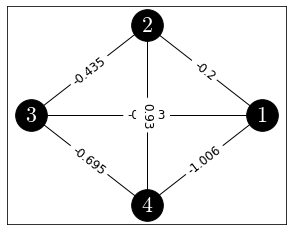

Ground state: -1.3592613101697637
Energy gap: 0.29462301692943105
Max excited state energy: 1.2722251638614956


In [2]:
# number of qubits
n = 4
n_edges = n*(n-1)//2

# ions chain parameters
nu_rad = 1e6
nu_ax = 0.15e6
mu = 2*np.pi*(nu_rad + 10e3) # in Hz
Omega_max = 2*np.pi*30e3     # in Hz

coupling_mat = radial_coupling_matrix(n, nu_rad, nu_ax, mu, Omega_max) # in kHz

# read data
index = 8 # data instance id from 1 to 100
# generate random Sherrington-Kirkpatrick instance
np.random.seed(100*index)
n_edges = n*(n-1)//2
weights = list(np.random.normal(size=n_edges))

G = get_weighted_graph(n,list(np.round(weights,3)))
pos = nx.circular_layout(G)

draw_graph(G, pos)

H2 = get_hamiltonian(n,weights)
gs = np.min(H2)
emax = np.max(H2)

spectrum = np.unique(np.sort(H2))

gap = spectrum[1] - spectrum[0]
print("Ground state:", gs)
print("Energy gap:", gap)
print("Max excited state energy:", emax)

### Train hyperparameters $A_j$

In [3]:
path = f'example_data/'
fname = f'{n}q_{index}.txt'
fname1 = path + fname

# read simulation parameters
n_iter = 30
max_restarts = 10
eps = 1e-3
tol_lvl = 0.5

np.random.seed(123*index)
training(path,fname,n,weights,coupling_mat,n_iter,tol_lvl,max_restarts,eps)

### Single-layered energy landscape

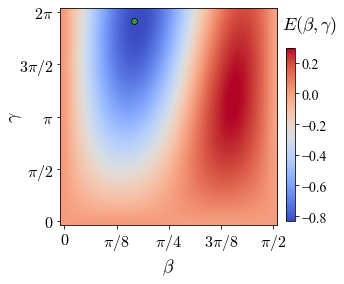

-0.8319332605207082 0.29430214692694023 [ 0.626857 -0.126385  0.054658  0.363933]


In [4]:
A = np.genfromtxt(fname1,skip_header=2)
H1 = ion_native_hamiltonian(n,A,coupling_mat)
Q = QAOA(1,H1,H2)
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(np.min(landscape),np.max(landscape),A)

### Rescale the hypeparameters to eliminate the narrow gorge

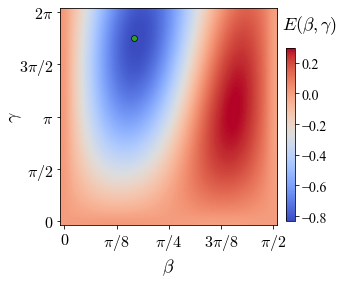

26875


In [5]:
A_rescaled, alpha, nfev = rescale_contr_params(n,A,H2,coupling_mat,k=25,eps=0.05)
H1_rescaled = ion_native_hamiltonian(n,A_rescaled,coupling_mat)
Q = QAOA(1,H1_rescaled,H2)
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(nfev)

### Single-layered energy for asymmetric $A_j$

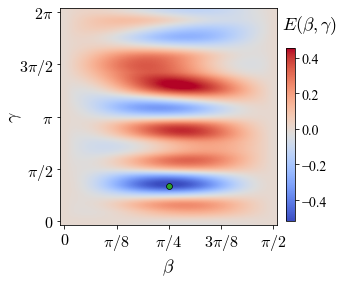

-0.5173348986649791


In [6]:
A_asym = np.ones(n)
A_asym[0] = -0.3
H1 = ion_native_hamiltonian(n,A_asym,coupling_mat)
Q = QAOA(1,H1,H2)
landscape = get_landscape(Q,k=25)
plot_landscape(landscape)
print(np.min(landscape))

### Evaluate the ion-native QAOA performance

#### Trained hyperparameters

In [7]:
p_max = 10

np.random.seed(12311)

H1 = ion_native_hamiltonian(n,A_rescaled,coupling_mat)
energies, angles, ovlp, r, nfev, exe_time = run_QAOA(H1,H2,p_max,method=0,n_runs=0)

pp = np.array(range(1,p_max+1))

data_trained = np.zeros((p_max,2))
data_trained[:,0] = pp
data_trained[:,1] = 1 - r

#### Asymmetric hyperparameters

In [8]:
np.random.seed(12551)

H1 = ion_native_hamiltonian(n,A_asym,coupling_mat)
energies1, angles1, ovlp1, r1, nfev1, exe_time1 = run_QAOA(H1,H2,p_max,method=0,n_runs=0)

data_asym = np.zeros((p_max,2))
data_asym[:,0] = pp
data_asym[:,1] = 1 - r1

### Plot fractional error

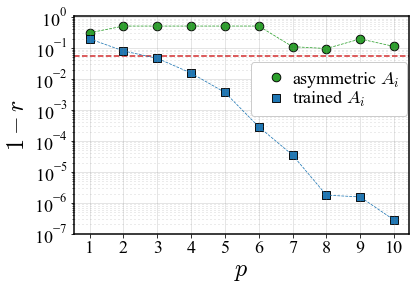

In [9]:
data_sets = [data_asym, data_trained]
labels = ['asymmetric $A_i$', 'trained $A_i$']
markers = ['o', 's']
colors = ['tab:green', 'tab:blue']

plot_energies_log(data_sets,labels,markers,colors,-gap/2.0/(gs - emax),1e-7)

In [63]:
import pennylane as qml
from pennylane import lie_closure
from pennylane import numpy as np
from pennylane.operation import Operator

def get_dla_generators_ion(n,A,coupling_mat):
    
    vA = A.reshape([n,1])
    ising_coupling_mat = (vA @ vA.T) * coupling_mat

    H1 = ion_native_hamiltonian(n,A,coupling_mat)
    
    obs = []
    coeffs = []

    for i in range(n):
        for j in range(i,n):
            if i!=j:
                coeffs.extend([ising_coupling_mat[i][j]])
                obs.extend([qml.PauliZ(i) @ qml.PauliZ(j)])
        
    H_ion = qml.Hamiltonian(coeffs,obs)
    
    assert np.sum(np.diag(H1) != np.real(H_ion.matrix()))==0, 'ion native Hamiltonians do not coincide'

    obs = []
    coeffs = []

    for i in range(n):
        coeffs.extend([1.0])
        obs.extend([qml.PauliX(i)])
    Hx = qml.Hamiltonian(coeffs,obs)

    generators = [H_ion, Hx]
    
    return generators
    
    
def get_dla_generators_qaoa(n,weights):
    
    obs = []
    coeffs = []
    
    w = weights.copy()
    
    H2 = get_hamiltonian(n,weights)

    for i in range(n):
        for j in range(i,n):
            if i!=j:
                coeffs.extend([w.pop(0)/np.sqrt(n)])
                obs.extend([qml.PauliZ(i) @ qml.PauliZ(j)])
        
    H = qml.Hamiltonian(coeffs,obs)
    
    assert np.sum(np.diag(H2) != np.real(H.matrix()))==0, 'Hamiltonians do not coincide'
    
    obs = []
    coeffs = []

    for i in range(n):
        coeffs.extend([1.0])
        obs.extend([qml.PauliX(i)])
    Hx = qml.Hamiltonian(coeffs,obs)

    generators = [H, Hx]
    
    return generators

In [59]:
generators_asym = get_dla_generators_ion(n,A_asym,coupling_mat)
dla = lie_closure(generators_asym,verbose=True,tol=0.001)
dim_g = len(dla)
print(dim_g)

epoch 1 of lie_closure, DLA size is 2
epoch 2 of lie_closure, DLA size is 3
epoch 3 of lie_closure, DLA size is 5
epoch 4 of lie_closure, DLA size is 10
epoch 5 of lie_closure, DLA size is 36
epoch 6 of lie_closure, DLA size is 123
epoch 7 of lie_closure, DLA size is 126
After 7 epochs, reached a DLA size of 126
126


In [60]:
generators_trained = get_dla_generators_ion(n,A_rescaled,coupling_mat)
dla_trained = lie_closure(generators_trained,verbose=True,tol=0.001)
dim_g_trained = len(dla_trained)
print(dim_g_trained)

epoch 1 of lie_closure, DLA size is 2
epoch 2 of lie_closure, DLA size is 3
epoch 3 of lie_closure, DLA size is 5
epoch 4 of lie_closure, DLA size is 10
epoch 5 of lie_closure, DLA size is 36
epoch 6 of lie_closure, DLA size is 126
After 6 epochs, reached a DLA size of 126
126


In [65]:
generators_qaoa = get_dla_generators_qaoa(n,weights)
dla_qaoa = lie_closure(generators_qaoa,verbose=True,tol=0.001)
dim_g_qaoa = len(dla_qaoa)
print(dim_g_qaoa)

epoch 1 of lie_closure, DLA size is 2
epoch 2 of lie_closure, DLA size is 3
epoch 3 of lie_closure, DLA size is 5
epoch 4 of lie_closure, DLA size is 10
epoch 5 of lie_closure, DLA size is 36
epoch 6 of lie_closure, DLA size is 124
epoch 7 of lie_closure, DLA size is 126
After 7 epochs, reached a DLA size of 126
126
